# GCE 17yr Analysis (haebarg, ported from Sanghwan 16yr `front_back`)

**Source**: `GC_analysis-60x60-models_front_back_16yr.ipynb` (Sanghwan)

**Conversion notes (2026-04-29)**
- All time/catalog/path knobs centralized in the CONFIG cell below. Edit there only — do not redefine `front`/`evtype_number` mid-notebook.
- `front` and `evtype_number` are now variables: toggle FRONT-only ↔ FRONT+BACK in one place.
- Mask scaling restored to **×1.0** (Cholis+2022 Table III original; was ×0.9 in 16yr).
- Catalog upgraded to **FL16Y** (DR=4, `gll_psc_v40.fit`).
- Sanghwan absolute paths replaced by CONFIG-driven f-strings.
- Cell 13 (400×400 CCUBE override) **disabled** — it broke `[100:500, 100:500]` slicing in main loop.

**Pre-flight checklist** (manual, before running):
1. `lat_spacecraft_merged_17yr.fits` exists in `../GCE_allsky_data/` (merge weekly SC files first).
2. 17yr photon weeklies present in `../GCE_allsky_data/photon_files/`.
3. `./GC_analysis/Model/` has: `wimp_map_CAR_wide.fits`, `Fermi_bubble_template.fits`, `isotropic_spectrum.txt`, `fermi_bubble_spectrum.txt`, `bubble_constraints.txt`, `iso_constraints_full_err.txt`, `egb_constraints_full_err.txt`, `empty_model.xml` (copy/symlink from prior 12yr or 16yr work).
4. Mapcubes available — set `MAPCUBE_DIR_*` in CONFIG.
5. FL16Y catalog file: `../GCE_17yr_data/gll_psc_v40.fit` (already in place per `GCE_analysis_directory_info.txt`).
6. Extended templates: `../GCE_17yr_data/LAT_extended_sources_16years/Templates/`.

**Known caveats** (carried from 16yr):
- Cell 36 contains legacy XML with `value="7*3*$"` — `$` would crash an f-string. It is wrapped in `'''...'''` so it is dead code; left untouched.
- Cell 59 is a 700-line monolithic main loop. On VSCode Jupyter the kernel can silent-kill on long runs — run small `model_list` chunks (cell 58) or run from a plain terminal Jupyter / nbconvert.
- Cells 60–119 are exploratory / dead code from 16yr development; left as-is. Only cells 0–59 are the active path.


> **v13 (2026-04-29)**: fixed cell 10 bin-generation bug. v12 used a while-loop with a floating-point break condition that silently produced 13 bins instead of the intended 14 (Cholis Table III). v13 uses direct concatenation of `first_bins[:-1] + second_bins` — explicit and unambiguous. The third tier (52→252 GeV) auto-extends if `ENERGY_BIN_MAX_GEV` exceeds 51.9, supporting the 17-bin front+back extension without code changes.


In [1]:
from GtApp import GtApp
import matplotlib.pyplot as plt
from astropy.visualization import astropy_mpl_style, wcsaxes #wcsaxes manages coordinates of the plot.
plt.style.use(astropy_mpl_style)
from astropy.io import fits
from astropy.utils.data import get_pkg_data_filename
from astropy.wcs import WCS #This package expresses coordinates of the image file.
import numpy as np
from astropy.table import Table, hstack
import xml.etree.ElementTree as ET
from astropy.coordinates import SkyCoord
import astropy.units as u
from LATSourceModel import SourceList
from scipy.interpolate import interp1d
import warnings
import numpy as np
import emcee
from chainconsumer import Chain, ChainConsumer
import pandas as pd
import matplotlib.pyplot as plt
from multiprocessing import Pool
import time
from scipy.interpolate import CubicSpline
from scipy.integrate import dblquad
import gt_apps as gt_apps
import os
from scipy.special import gammaln


In [2]:
# ==================================================================
# 17yr GCE Analysis CONFIG - haebarg server (v6)
# ==================================================================
# Edit ONLY here. Both notebooks (main + covariance) share this CONFIG.
# Run notebooks from:
#   /home/haebarg/GCE-Chi-square-fitting/GCE_17yr_reproduce/
# ------------------------------------------------------------------

import os

# ---- Event type / IRF ---------------------------------------------
# Default: FRONT-only (evtype=1) for direct comparison with Cholis+2022.
# To switch back to FRONT+BACK (16yr Sanghwan default):
#     front='_front_back', evtype_number=3
front          = '_front'              # filename suffix
evtype_number  = 1                     # 1=FRONT only, 3=FRONT+BACK
evclass_number = 256                   # 256 = CLEAN
IRFS           = 'P8R3_CLEAN_V3'

# ---- Mask scaling --------------------------------------------------
MASK_SCALE = 1.0     # x1.0 (Cholis Table III). 16yr used x0.9 (undocumented).

# ---- Energy bins ---------------------------------------------------
# Default 51.9 GeV cap = 14 bins matching the mask definition (Cholis Table III).
# Set to 1000.0 to extend to ~550 GeV (17 bins, 16yr default).
ENERGY_BIN_MAX_GEV = 51.9

# ---- Catalog: FL16Y -----------------------------------------------
DR_NUMBER       = 4
CATALOG_FILE    = '../GCE_17yr_data/gll_psc_v40.fit'
CATALOG_SUFFIX  = '_FL16Y'
EXTENDED_DIR    = '../GCE_17yr_data/LAT_extended_sources_16years/Templates/'

# ---- Diffuse + isotropic ------------------------------------------
GALACTIC_FILE   = '../gll_iem_v07.fits'
ISOTROPIC_FILE  = '../iso_P8R3_CLEAN_V3_v1.txt'

# ---- Photon input (gtselect handles @listfile fine) --------------
PHOTON_LIST_FILE   = 'photon_data_17yr.txt'
PHOTON_INPUT       = PHOTON_LIST_FILE
PHOTON_WEEKLY_GLOB = '../GCE_allsky_data/photon_files/lat_photon_weekly_w*.fits'

# ---- Spacecraft input ---------------------------------------------
# IMPORTANT: gtmktime does NOT accept @listfile reliably -- it returns
# "Zero rows returned from FT2 file" even with valid weeklies in the list.
# Fix: pre-flight auto-merges SC weeklies into a single FT2 file using
# astropy (memory-safe at SC scale). gtmktime then receives this single file.
SC_MERGED_FILE = '../GCE_allsky_data/lat_spacecraft_merged_17yr.fits'
SC_FILE        = SC_MERGED_FILE                     # what gets fed to gtmktime/gtltcube
SC_WEEKLY_GLOB = '../GCE_allsky_data/sc_files/lat_spacecraft_weekly_w*.fits'
SC_LIST_FILE   = 'sc_files_17yr.txt'                # listfile (kept for diagnostics; not used)

# Time window: 'INDEF' uses the whole spacecraft file
TMIN = 'INDEF'
TMAX = 'INDEF'

# ---- Templates / spectra (haebarg actual file names) --------------
WIMP_MAP_PATH        = './GCE_template_NFW2.fits'
BUBBLE_TEMPLATE      = './Fermi_Bubbles_template.fits'
ISO_SPECTRUM_FILE    = './isotropic_spectrum_ff.txt'
BUBBLE_SPECTRUM_FILE = './fermi_bubble_spectrum.txt'

# ---- GDE Mapcubes -------------------------------------------------
MAPCUBE_DIR_PION   = './MapCubes'
MAPCUBE_DIR_BREMSS = './MapCubes'
MAPCUBE_DIR_ICS    = './MapCubes'
MAPCUBE_EXT        = '.fits'

# ---- External constraints (12yr files; reuse) ---------------------
ISO_CONSTRAINT_FILE     = './GC_analysis_FL16Y/Model/iso_constraints_full_err.txt'
EGB_CONSTRAINT_FILE     = './GC_analysis_FL16Y/Model/egb_constraints_full_err.txt'
BUBBLE_CONSTRAINT_FILE  = './GC_analysis_FL16Y/Model/bubble_constraints.txt'

# ---- Model list ---------------------------------------------------
# Default: full 80 GDE models. Set to a list to restrict, e.g.:
#   MODEL_LIST_OVERRIDE = ['X']  # single model
#   MODEL_LIST_OVERRIDE = ['X', 'XLIX', 'I']  # subset
MODEL_LIST_OVERRIDE = None

# ---- Working / output directory -----------------------------------
WORK_DIR = './GC_analysis_FL16Y'
os.makedirs(f'{WORK_DIR}/Model', exist_ok=True)

# ---- Existing-models tracker --------------------------------------
EXISTING_MODELS_TXT = f'./GCE_17yr{front}_existing_models.txt'

print("17yr CONFIG (v6) loaded:")
print(f"  Event type   : front='{front}', evtype={evtype_number}")
print(f"  Mask scale   : x{MASK_SCALE}")
print(f"  Energy cap   : {ENERGY_BIN_MAX_GEV} GeV")
print(f"  Catalog      : DR={DR_NUMBER}, {CATALOG_FILE}")
print(f"  Photon input : {PHOTON_INPUT}")
print(f"  SC input     : {SC_FILE}")
print(f"  Working dir  : {WORK_DIR}")
print(f"  Models       : {'override='+str(MODEL_LIST_OVERRIDE) if MODEL_LIST_OVERRIDE else 'all 80'}")


17yr CONFIG (v6) loaded:
  Event type   : front='_front', evtype=1
  Mask scale   : x1.0
  Energy cap   : 51.9 GeV
  Catalog      : DR=4, ../GCE_17yr_data/gll_psc_v40.fit
  Photon input : photon_data_17yr.txt
  SC input     : ../GCE_allsky_data/lat_spacecraft_merged_17yr.fits
  Working dir  : ./GC_analysis_FL16Y
  Models       : all 80


## Pre-flight: prepare inputs + verify

`PHOTON_INPUT` defaults to the **listfile** form (`photon_data_17yr.txt`) - gtselect reads the listed weeklies directly, no merge step. Pre-flight auto-generates both photon + SC listfiles if missing and confirms every entry exists.

Switch to a merged photon FITS by changing `PHOTON_INPUT` in CONFIG (only worth it if `ftmerge` is available - the in-memory Python merge scripts OOM at 17yr scale).


In [3]:
# Pre-flight: prepare photon listfile + merged SC FT2 + verify all inputs.
# Memory-safe SC merge (each SC weekly is ~few MB; 925 files ~few GB total).
import os
import re
import glob
import numpy as np
from astropy.io import fits
from astropy.table import Table, vstack


def _generate_listfile(listfile, glob_pattern, label):
    """Generate listfile from glob_pattern if missing. Uses absolute paths."""
    if os.path.exists(listfile):
        with open(listfile) as f:
            n = sum(1 for ln in f if ln.strip())
        print(f"[{label:<10}] {listfile} exists ({n} entries)")
        return
    paths = sorted(glob.glob(glob_pattern))
    if not paths:
        raise FileNotFoundError(
            f"\n[{label:<10}] no files match {glob_pattern}"
        )
    paths = [os.path.abspath(p) for p in paths]
    with open(listfile, 'w') as f:
        f.write('\n'.join(paths) + '\n')
    print(f"[{label:<10}] generated {listfile} with {len(paths)} entries")


def _verify_listfile(listfile, label, expected_min_week=None):
    with open(listfile) as f:
        entries = [ln.strip() for ln in f if ln.strip()]
    missing = [p for p in entries if not os.path.exists(p)]
    if missing:
        raise FileNotFoundError(
            f"[{label:<10}] {len(missing)} entries do not exist on disk."
        )
    nums = sorted({int(m.group(1))
                   for p in entries
                   for m in [re.search(r'_w(\\d+)_', os.path.basename(p))]
                   if m})
    if nums:
        last = nums[-1]
        print(f"[{label:<10}] {len(entries)} files, week range w{nums[0]:03d}..w{last:03d}")
        if expected_min_week is not None and last < expected_min_week:
            print(f"[{label:<10}] WARN: last week is w{last}.")


def merge_sc_weeklies(out_path, sc_glob):
    """Merge LAT spacecraft weeklies into a single FT2 file.
    SC files are small (~few MB each) so this is memory-safe."""
    if os.path.exists(out_path):
        print(f"[SC merge ] exists: {out_path} ({os.path.getsize(out_path)/1e9:.2f} GB)")
        return

    files = sorted(glob.glob(sc_glob))
    if not files:
        raise FileNotFoundError(f"[SC merge ] no files at {sc_glob}")

    print(f"[SC merge ] reading {len(files)} weeklies...")
    sc_tables, gti_starts, gti_stops = [], [], []
    primary_hdr = sc_data_hdr = gti_hdr = None

    for i, fn in enumerate(files):
        with fits.open(fn, memmap=False) as hdul:
            names = [h.name for h in hdul]
            if primary_hdr is None:
                primary_hdr = hdul[0].header.copy()
            if sc_data_hdr is None and 'SC_DATA' in names:
                sc_data_hdr = hdul['SC_DATA'].header.copy()
            if gti_hdr is None and 'GTI' in names:
                gti_hdr = hdul['GTI'].header.copy()

            if 'SC_DATA' not in names:
                print(f"  WARN: no SC_DATA in {os.path.basename(fn)}")
                continue
            sc_tables.append(Table(hdul['SC_DATA'].data))

            if 'GTI' in names and len(hdul['GTI'].data) > 0:
                gti = hdul['GTI'].data
                gti_starts.extend(list(gti['START']))
                gti_stops.extend(list(gti['STOP']))

        if (i + 1) % 100 == 0:
            print(f"  ... {i+1}/{len(files)}")

    print(f"[SC merge ] stacking {len(sc_tables)} tables...")
    merged_sc = vstack(sc_tables)
    merged_sc.sort('START')
    new_tstart = float(merged_sc['START'][0])
    new_tstop  = float(merged_sc['STOP'][-1])
    span_yr = (new_tstop - new_tstart) / (365.25 * 86400)
    print(f"[SC merge ] {len(merged_sc):,} rows, span={span_yr:.2f} yr")

    # Sort GTIs by START
    gti_starts_arr = np.array(gti_starts)
    gti_stops_arr  = np.array(gti_stops)
    if len(gti_starts_arr) > 0:
        order = np.argsort(gti_starts_arr)
        gti_starts_arr = gti_starts_arr[order]
        gti_stops_arr  = gti_stops_arr[order]

    primary_hdu = fits.PrimaryHDU(header=primary_hdr)
    primary_hdu.header['TSTART'] = new_tstart
    primary_hdu.header['TSTOP']  = new_tstop

    sc_hdu = fits.BinTableHDU(merged_sc, header=sc_data_hdr, name='SC_DATA')
    sc_hdu.header['TSTART'] = new_tstart
    sc_hdu.header['TSTOP']  = new_tstop

    gti_cols = [
        fits.Column(name='START', format='D', array=gti_starts_arr),
        fits.Column(name='STOP',  format='D', array=gti_stops_arr),
    ]
    gti_hdu = fits.BinTableHDU.from_columns(gti_cols, name='GTI')
    if gti_hdr is not None:
        for key in ('TIMESYS', 'MJDREFI', 'MJDREFF', 'TIMEUNIT',
                    'TIMEREF', 'TASSIGN'):
            if key in gti_hdr:
                gti_hdu.header[key] = gti_hdr[key]
    gti_hdu.header['TSTART'] = new_tstart
    gti_hdu.header['TSTOP']  = new_tstop

    print(f"[SC merge ] writing {out_path}...")
    fits.HDUList([primary_hdu, sc_hdu, gti_hdu]).writeto(out_path, overwrite=False)
    sz = os.path.getsize(out_path) / 1e9
    print(f"[SC merge ] done ({sz:.2f} GB)")


# ----- Photon: listfile -----------------------------------------------
def verify_photon_input():
    if not os.path.exists(PHOTON_INPUT):
        if PHOTON_INPUT == PHOTON_LIST_FILE:
            _generate_listfile(PHOTON_LIST_FILE, PHOTON_WEEKLY_GLOB, 'Photon')
        else:
            raise FileNotFoundError(
                f"PHOTON_INPUT {PHOTON_INPUT} does NOT exist."
            )
    if PHOTON_INPUT.endswith('.txt'):
        _verify_listfile(PHOTON_INPUT, 'Photon', expected_min_week=900)
    else:
        with fits.open(PHOTON_INPUT) as h:
            print(f"[Photon   ] merged: {len(h['EVENTS'].data):,} events")


# ----- SC: merge weeklies into single FT2 ----------------------------
def verify_sc_input():
    # Generate listfile too (kept for diagnostics)
    _generate_listfile(SC_LIST_FILE, SC_WEEKLY_GLOB, 'SC list')
    _verify_listfile(SC_LIST_FILE, 'SC list', expected_min_week=900)

    # The merged FT2 is what gtmktime/gtltcube actually use
    merge_sc_weeklies(SC_MERGED_FILE, SC_WEEKLY_GLOB)

    # Sanity-check the merged SC file
    with fits.open(SC_MERGED_FILE) as h:
        n_rows = len(h['SC_DATA'].data)
        tstart = float(h['SC_DATA'].header.get('TSTART', 0))
        tstop  = float(h['SC_DATA'].header.get('TSTOP', 0))
        span_yr = (tstop - tstart) / (365.25 * 86400) if tstop > 0 else 0
        print(f"[SC merged] {n_rows:,} rows, span={span_yr:.2f} yr")


verify_photon_input()
verify_sc_input()
print("\n[OK] photon listfile + merged SC FT2 ready.")


[SC list   ] sc_files_17yr.txt exists (924 entries)
[SC merge ] exists: ../GCE_allsky_data/lat_spacecraft_merged_17yr.fits (2.58 GB)
[SC merged] 15,730,239 rows, span=17.71 yr

[OK] photon listfile + merged SC FT2 ready.


## Data preparation part

In [4]:
def galactic_to_equatorial(l, b):
    # Create a SkyCoord object with Galactic coordinates
    galactic_coord = SkyCoord(l=l*u.degree, b=b*u.degree, frame='galactic')

    # Convert to J2000 equatorial coordinates
    equatorial_coord = galactic_coord.icrs

    # Extract RA and Dec
    ra = equatorial_coord.ra.degree
    dec = equatorial_coord.dec.degree

    return ra, dec

In [5]:
def equatorial_to_galactic(ra, dec):
    # Create a SkyCoord object with equatorial coordinates (J2000)
    equatorial_coord = SkyCoord(ra=ra*u.degree, dec=dec*u.degree, frame='icrs')

    # Convert to Galactic coordinates
    galactic_coord = equatorial_coord.galactic

    # Extract l and b
    l = galactic_coord.l.degree
    b = galactic_coord.b.degree

    return l, b

In [6]:
RA, DEC = galactic_to_equatorial(0, 0) #Coordinate for GC

In [7]:
# Define energy bin edges and write bin_definitions.fits.
# 14 bins by default (Cholis Table III, matching mask definitions).
# 17 bins if ENERGY_BIN_MAX_GEV is raised above ~250 GeV (front+back extension).
#
# Note (v13): cell 10 in v12 had a floating-point comparison bug that
# silently produced 13 bins. This version uses direct concatenation of
# the Cholis-defined first_bins and second_bins (and an optional third
# tier) — no fragile while-loop.

import numpy as np

bin_def_txt  = f'{WORK_DIR}/bin_definitions.txt'
bin_def_fits = f'{WORK_DIR}/bin_definitions.fits'

if os.path.exists(bin_def_fits):
    # Sanity check: warn if existing file has wrong bin count
    from astropy.io import fits as _f
    _existing_bins = _f.open(bin_def_fits)[1].data
    _f.open(bin_def_fits).close()
    print(f'[skip] {bin_def_fits} exists with {len(_existing_bins)} bins')
    if len(_existing_bins) != 14 and ENERGY_BIN_MAX_GEV <= 100:
        print(f'[WARN] expected 14 bins for ENERGY_BIN_MAX_GEV={ENERGY_BIN_MAX_GEV} GeV')
        print(f'[WARN] delete bin_definitions.{{txt,fits}} and re-run this cell')
else:
    # Cholis Table III low-energy bins (12 edges, 11 bins, 0.275-4.91 GeV)
    first_bins  = np.array([0.275, 0.357, 0.464, 0.603, 0.784, 1.02, 1.32, 1.72,
                            2.24, 2.91, 3.78, 4.91])
    # High-energy bins (Cholis Table III: 4.91 → 10.8 → 23.7 → 51.9 GeV)
    second_bins = np.array([4.91, 10.8, 23.7, 51.9])
    # log10 step factor between high-energy bins (~0.342 dex, ~2.20x)
    log_width   = np.log10(second_bins[1]) - np.log10(second_bins[0])

    # Direct concatenation: drop duplicate 4.91 in first_bins to merge cleanly.
    # → 12 + 4 - 1 = 15 edges = 14 bins, range 0.275-51.9 GeV.
    edges = list(first_bins[:-1]) + list(second_bins)

    # Optional extension to higher energies (for ENERGY_BIN_MAX_GEV > 51.9).
    # Keeps the same log_width as the high-energy tier.
    while edges[-1] < ENERGY_BIN_MAX_GEV - 1e-3:
        next_edge = edges[-1] * 10**log_width
        if next_edge > ENERGY_BIN_MAX_GEV + 1e-3:
            break
        edges.append(next_edge)

    edges = np.array(edges)

    with open(bin_def_txt, 'w') as f:
        for i in range(len(edges) - 1):
            f.write(f"{edges[i]:.3f} {edges[i+1]:.3f}\n")

    bindef = GtApp('gtbindef')
    bindef['bintype']     = 'E'
    bindef['binfile']     = bin_def_txt
    bindef['outfile']     = bin_def_fits
    bindef['energyunits'] = 'GeV'
    bindef.run()
    n_bins = len(edges) - 1
    print(f'[done] {n_bins} energy bins, {edges[0]:.3f} - {edges[-1]:.3f} GeV')
    print(f'       written to {bin_def_fits}')
    if n_bins != 14 and ENERGY_BIN_MAX_GEV <= 100:
        print(f'[WARN] expected 14 bins for ENERGY_BIN_MAX_GEV={ENERGY_BIN_MAX_GEV} GeV — got {n_bins}')



[skip] ./GC_analysis_FL16Y/bin_definitions.fits exists with 14 bins


In [8]:
# Data preparation: gtselect → gtmktime → gtbin (CCUBE).
# Each step skipped if its output already exists (re-run is cheap).

select_out = f'{WORK_DIR}/Allsky_select_17yr{front}_clean.fits'
gti_out    = f'{WORK_DIR}/Allsky_gti_17yr{front}_clean.fits'
ccube_out  = f'{WORK_DIR}/GC_ccube_17yr{front}_clean.fits'

# --- gtselect (slow if PHOTON_INPUT is a listfile of weeklies) ---
if os.path.exists(select_out):
    print(f'[skip] gtselect : {select_out}')
else:
    print(f'[run ] gtselect -> {select_out}')
    filters = GtApp('gtselect', 'dataSubselector')
    filters['evclass'] = evclass_number
    filters['evtype']  = evtype_number
    filters['ra']      = 'INDEF'
    filters['dec']     = 'INDEF'
    filters['rad']     = 'INDEF'
    filters['emin']    = 100
    filters['emax']    = 1000000
    filters['zmax']    = 100
    filters['tmin']    = TMIN
    filters['tmax']    = TMAX
    filters['infile']  = PHOTON_INPUT
    filters['outfile'] = select_out
    filters.run()

# --- gtmktime ---
if os.path.exists(gti_out):
    print(f'[skip] gtmktime : {gti_out}')
else:
    print(f'[run ] gtmktime -> {gti_out}')
    maketime = GtApp('gtmktime', 'dataSubselector')
    maketime['scfile']  = SC_FILE
    maketime['filter']  = 'DATA_QUAL==1 && LAT_CONFIG==1 && ABS(ROCK_ANGLE) < 52'
    maketime['roicut']  = 'no'
    maketime['evfile']  = select_out
    maketime['outfile'] = gti_out
    maketime.run()

# --- gtbin (CCUBE 600x600 0.1 deg) ---
if os.path.exists(ccube_out):
    print(f'[skip] gtbin    : {ccube_out}')
else:
    print(f'[run ] gtbin    -> {ccube_out}')
    counts_map = GtApp('gtbin', 'evtbin')
    counts_map['algorithm'] = 'CCUBE'
    counts_map['evfile']    = gti_out
    counts_map['outfile']   = ccube_out
    counts_map['nxpix']     = 600
    counts_map['nypix']     = 600
    counts_map['binsz']     = 0.1
    counts_map['coordsys']  = 'GAL'
    counts_map['xref']      = 0
    counts_map['yref']      = 0
    counts_map['axisrot']   = 0
    counts_map['proj']      = 'CAR'
    counts_map['ebinalg']   = 'FILE'
    counts_map['ebinfile']  = f'{WORK_DIR}/bin_definitions.fits'
    counts_map.run()


[skip] gtselect : ./GC_analysis_FL16Y/Allsky_select_17yr_front_clean.fits
[skip] gtmktime : ./GC_analysis_FL16Y/Allsky_gti_17yr_front_clean.fits
[skip] gtbin    : ./GC_analysis_FL16Y/GC_ccube_17yr_front_clean.fits


> **Cell 13 disabled** (Fix 2): the 400×400 CCUBE would have overwritten the 600×600 CCUBE from cell 12, breaking the `[100:500, 100:500]` slicing in the main loop. See project note `REF_12yr_final_code_for_17yr_SUMMARY.md`.


In [9]:
# gtltcube: livetime cube (slow on 17yr scale; skip if exists)
ltcube_out = f'{WORK_DIR}/Allsky_ltcube_17yr{front}_clean.fits'

if os.path.exists(ltcube_out):
    print(f'[skip] gtltcube : {ltcube_out}')
else:
    print(f'[run ] gtltcube -> {ltcube_out}')
    ltCube = GtApp('gtltcube', 'Likelihood')
    ltCube['evfile']    = f'{WORK_DIR}/Allsky_gti_17yr{front}_clean.fits'
    ltCube['scfile']    = SC_FILE
    ltCube['outfile']   = ltcube_out
    ltCube['dcostheta'] = 0.025
    ltCube['binsz']     = 1
    ltCube['zmax']      = 100
    ltCube.run()


[skip] gtltcube : ./GC_analysis_FL16Y/Allsky_ltcube_17yr_front_clean.fits


In [10]:
# gtexpcube2 (center): exposure cube for the GC ROI
expcube_out = f'{WORK_DIR}/GC_expcube_center_17yr{front}_clean.fits'

if os.path.exists(expcube_out):
    print(f'[skip] gtexpcube2 center : {expcube_out}')
else:
    print(f'[run ] gtexpcube2 center -> {expcube_out}')
    gtexpcube2 = GtApp('gtexpcube2', 'Likelihood')
    gtexpcube2['infile']    = f'{WORK_DIR}/Allsky_ltcube_17yr{front}_clean.fits'
    gtexpcube2['cmap']      = 'none'
    gtexpcube2['outfile']   = expcube_out
    gtexpcube2['evtype']    = evtype_number
    gtexpcube2['coordsys']  = 'GAL'
    gtexpcube2['xref']      = 0
    gtexpcube2['yref']      = 0
    gtexpcube2['nxpix']     = 600
    gtexpcube2['nypix']     = 600
    gtexpcube2['proj']      = 'CAR'
    gtexpcube2['binsz']     = 0.1
    gtexpcube2['bincalc']   = 'CENTER'
    gtexpcube2['irfs']      = IRFS
    gtexpcube2['ebinalg']   = 'FILE'
    gtexpcube2['ebinfile']  = f'{WORK_DIR}/bin_definitions.fits'
    gtexpcube2.run()


[skip] gtexpcube2 center : ./GC_analysis_FL16Y/GC_expcube_center_17yr_front_clean.fits


In [11]:
# gtexpcube2 (edge): all-sky exposure for source-list edge handling
expcube_edge_out = f'{WORK_DIR}/Allsky_expcube_edge_17yr{front}_clean.fits'

if os.path.exists(expcube_edge_out):
    print(f'[skip] gtexpcube2 edge : {expcube_edge_out}')
else:
    print(f'[run ] gtexpcube2 edge -> {expcube_edge_out}')
    gtexpcube2 = GtApp('gtexpcube2', 'Likelihood')
    gtexpcube2['infile']    = f'{WORK_DIR}/Allsky_ltcube_17yr{front}_clean.fits'
    gtexpcube2['cmap']      = 'none'
    gtexpcube2['outfile']   = expcube_edge_out
    gtexpcube2['evtype']    = evtype_number
    gtexpcube2['coordsys']  = 'GAL'
    gtexpcube2['xref']      = 0
    gtexpcube2['yref']      = 0
    gtexpcube2['nxpix']     = 3600
    gtexpcube2['nypix']     = 1800
    gtexpcube2['proj']      = 'CAR'
    gtexpcube2['binsz']     = 0.1
    gtexpcube2['bincalc']   = 'EDGE'
    gtexpcube2['irfs']      = IRFS
    gtexpcube2['ebinalg']   = 'FILE'
    gtexpcube2['ebinfile']  = f'{WORK_DIR}/bin_definitions.fits'
    gtexpcube2.run()


[skip] gtexpcube2 edge : ./GC_analysis_FL16Y/Allsky_expcube_edge_17yr_front_clean.fits


In [12]:
# Build source XML model from FL16Y catalog.
xml_out = f'{WORK_DIR}/Model/GC_model_FL16Y.xml'

if os.path.exists(xml_out):
    print(f'[skip] SourceList: {xml_out}')
else:
    print(f'[run ] SourceList -> {xml_out}')
    source_list = SourceList(
        DR=DR_NUMBER,
        catalog_file=CATALOG_FILE,
        ROI=[266, -29, 35],
        output_name='GC_model_FL16Y.xml',
        write_directory=f'{WORK_DIR}/Model/',
    )
    source_list.make_model(
        extended_catalog_names=True,
        norms_free_only=True,
        galactic_index_free=True,
        extra_radius=5,
        free_radius=28.28,
        max_free_radius=28.28,
        variable_free=True,
        sigma_to_free=49,
        galactic_name='gll_iem',
        galactic_file=GALACTIC_FILE,
        isotropic_file=ISOTROPIC_FILE,
        isotropic_name='isotropic',
        extended_directory=EXTENDED_DIR,
    )


[run ] SourceList -> ./GC_analysis_FL16Y/Model/GC_model_FL16Y.xml
Creating spatial and spectral model from the 4FGL DR-4 catalog: ../GCE_17yr_data/gll_psc_v40.fit.


Extended source FL16Y J1713.5-3945e in model, make sure that the following path to extended template is correct: ../GCE_17yr_data/LAT_extended_sources_16years/Templates/RXJ1713_2016_250GeV.fits
Extended source FL16Y J1840.9-0532e in model, make sure that the following path to extended template is correct: ../GCE_17yr_data/LAT_extended_sources_16years/Templates/HESSJ1841-055.fits
Extended source FL16Y J1552.9-5607e in model, make sure that the following path to extended template is correct: ../GCE_17yr_data/LAT_extended_sources_16years/Templates/MSH15-56_SNRmask.fits
Extended source FL16Y J1552.4-5612e in model, make sure that the following path to extended template is correct: ../GCE_17yr_data/LAT_extended_sources_16years/Templates/MSH15-56_PWN.fits
Extended source FL16Y J1855.9+0121e in model, make sure that the following path to extended template is correct: ../GCE_17yr_data/LAT_extended_sources_16years/Templates/W44.fits
Added 1377 point sources and 35 extended sources.
If you plan 

In [13]:
# Remove the catalog's isotropic + galactic-diffuse entries from the XML
# (we add our own, configured ones in the main loop).
xml_in  = f'{WORK_DIR}/Model/GC_model_FL16Y.xml'
xml_out = f'{WORK_DIR}/Model/GC_psc_model_FL16Y.xml'

if os.path.exists(xml_out):
    print(f'[skip] XML prune: {xml_out}')
else:
    print(f'[run ] XML prune -> {xml_out}')
    tree = ET.parse(xml_in)
    root = tree.getroot()
    for source in list(root.findall(".//source")):
        name = source.get('name', '')
        if 'isotropic' in name or 'gll_iem' in name:
            root.remove(source)
    tree.write(xml_out, encoding='utf-8', xml_declaration=True)


[run ] XML prune -> ./GC_analysis_FL16Y/Model/GC_psc_model_FL16Y.xml


In [14]:

# Define the names of the sources you want to remove

# Parse the existing XML file

ra_dec_values = []
spatial_ra_dec_values = []
tree = ET.parse('./GC_analysis_FL16Y/Model/GC_psc_model_FL16Y.xml')
root = tree.getroot()

# Find and remove the elements
for source in root.findall(".//source"):
    source_name = source.attrib.get('name', '')
    source_type = source.attrib.get('type', '')
    if source_type=='PointSource':
        #for param in source.findall(".//spectrum/parameter"):
        ra = float(source.find(".//spatialModel/parameter[@name='RA']").attrib['value'])
        dec = float(source.find(".//spatialModel/parameter[@name='DEC']").attrib['value'])
        l, b = equatorial_to_galactic(ra, dec)
        if True:#is_within_roi(l, b):
            #name = source.attrib['name']
            ra_dec_values.append([source_name, ra, dec])
        else:
            print(source_name, l, b)
            
    if source_type == "DiffuseSource":
        spatial_model = source.find(".//spatialModel")
        if spatial_model is not None:# and source.attrib['type']=='SpatialMap':
            if spatial_model.attrib.get('type') == 'SpatialMap':
                file_path = spatial_model.attrib.get('file')
                if file_path:
                    ra = fits.open(file_path)[0].header['CRVAL1']
                    dec = fits.open(file_path)[0].header['CRVAL2']
                    l, b = equatorial_to_galactic(ra, dec)
                    if True:#is_within_roi(l, b):
                    #spatial_ra_dec_values.append([source_name, ra, dec])
                    #ra_dec_values.append([source_name, ra, dec])
                        spatial_ra_dec_values.append([source_name, ra, dec])
            if spatial_model.attrib.get('type') != 'SpatialMap':
                ra = float(source.find(".//spatialModel/parameter[@name='RA']").attrib['value'])
                dec = float(source.find(".//spatialModel/parameter[@name='DEC']").attrib['value'])
                l, b = equatorial_to_galactic(ra, dec)
                if True:#is_within_roi(l, b):
                #spatial_ra_dec_values.append([source_name, ra, dec])
                #ra_dec_values.append([source_name, ra, dec])
                    spatial_ra_dec_values.append([source_name, ra, dec])

In [15]:
#not_sig_ra_dec_values=ra_dec_values.copy()
not_sig_ra_dec_values = ra_dec_values + spatial_ra_dec_values
sig_ra_dec_values=[]
data=fits.open(CATALOG_FILE)[1].data    # FL16Y v40 from CONFIG
for row in data:
    for lists in not_sig_ra_dec_values:
        if row['Source_Name'] == lists[0]:
            if row['Signif_Avg'] > 49:
                sig_ra_dec_values.append(lists)
                not_sig_ra_dec_values.remove(lists)
                print(row['Source_Name'], row['Signif_Avg'], lists)
                #sig_ra_dec_values.pop(index)


FL16Y J1443.9-3908 100.98371 ['FL16Y J1443.9-3908', 220.9877, -39.1474]
FL16Y J1457.4-3539 82.834045 ['FL16Y J1457.4-3539', 224.366, -35.6532]
FL16Y J1509.4-5850 80.61517 ['FL16Y J1509.4-5850', 227.3586, -58.8472]
FL16Y J1514.2-4946 89.383835 ['FL16Y J1514.2-4946', 228.5731, -49.7711]
FL16Y J1517.6-2422 119.31627 ['FL16Y J1517.6-2422', 229.4242, -24.3681]
FL16Y J1521.9-5735 56.21151 ['FL16Y J1521.9-5735', 230.4828, -57.5917]
FL16Y J1532.7-1319 63.71278 ['FL16Y J1532.7-1319', 233.1973, -13.3278]
FL16Y J1536.3-4948 121.45466 ['FL16Y J1536.3-4948', 234.0947, -49.8146]
FL16Y J1603.8-4903 70.24919 ['FL16Y J1603.8-4903', 240.9674, -49.0655]
FL16Y J1614.5-2230 70.984 ['FL16Y J1614.5-2230', 243.6416, -22.5035]
FL16Y J1620.6-4927 86.032265 ['FL16Y J1620.6-4927', 245.1725, -49.4626]
FL16Y J1625.1-0021 69.93713 ['FL16Y J1625.1-0021', 246.2893, -0.3562]
FL16Y J1653.6-0158 70.1211 ['FL16Y J1653.6-0158', 253.4042, -1.9699]
FL16Y J1702.8-5655 54.921497 ['FL16Y J1702.8-5655', 255.7072, -56.9316]
FL16Y

In [16]:
# E_bounds: per-bin energy edges from the CCUBE; E = geometric-mean energies (GeV).
E_bounds = fits.open(f'{WORK_DIR}/GC_ccube_17yr{front}_clean.fits')[1].data
E = np.zeros(len(E_bounds))
for i in range(len(E_bounds)):
    E[i] = 1e-3 * np.sqrt(E_bounds[i][2] * E_bounds[i][1] * 1e-6)   # MeV -> GeV
print(f'E ({len(E)} bins): {E[0]:.3f} - {E[-1]:.3f} GeV')


E (14 bins): 0.313 - 35.072 GeV


In [17]:
## Corrected code
def masking(significance, locations, energy, image_file): #Input GeV, location ra dec, radius theta
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    warnings.filterwarnings("ignore", message="'datfix' made the change")

    data = [
    [0.275, 0.357, 1.125, 3.75],
    [0.357, 0.464, 0.975, 3.25],
    [0.464, 0.603, 0.788, 2.63],
    [0.603, 0.784, 0.600, 2.00],
    [0.784, 1.02, 0.450, 1.50],
    [1.02, 1.32, 0.375, 1.25],
    [1.32, 1.72, 0.300, 1.00],
    [1.72, 2.24, 0.225, 0.750],
    [2.24, 2.91, 0.188, 0.625],
    [2.91, 3.78, 0.162, 0.540],
    [3.78, 4.91, 0.125, 0.417],
    [4.91, 10.8, 0.100, 0.333],
    [10.8, 23.7, 0.060, 0.200],
    [23.7, 51.9, 0.053, 0.175]] #Mask definition is taken from 2112.09706v2, Table III
    data=np.asarray(data)
    
    mask_energy=np.sqrt(data[0:, 0]*data[0:, 1])
    mask_small=data[0:, 2]*MASK_SCALE
    mask_large=data[0:, 3]*MASK_SCALE
    

    mask_small_int=interp1d(mask_energy, mask_small, fill_value='extrapolate')
    mask_large_int=interp1d(mask_energy, mask_large, fill_value='extrapolate')
    
    
    mask_small_size=(mask_small_int(energy))
    mask_large_size=(mask_large_int(energy))

    mask_small_size[mask_small_size<=0] = 0
    mask_large_size[mask_large_size<=0] = 0

    mask_small_size = mask_small_size
    mask_large_size = mask_large_size
    
    print(energy, mask_small_size, mask_large_size)

    fits_file = image_file
    hdulist = fits.open(fits_file)
    data = hdulist[0].data[0]  # Assuming the image data is in the first extension
    header = hdulist[0].header

    masked_data = np.ones(np.shape(data))
    # Get WCS information from the header
    wcs = WCS(header).dropaxis(2)
    
    for points in locations:
        #print(points[0])
        l, b = equatorial_to_galactic(float(points[1]), float(points[2]))
        #print(l, b)
        # Define your point of interest in Galactic coordinates
        # Convert Galactic coordinates to Equatorial coordinates (RA, Dec)
        galactic_coords = SkyCoord(l=l*u.degree, b=b*u.degree, frame='galactic')
        #equatorial_coords = galactic_coords.icrs

        
        # Convert Equatorial coordinates to pixel coordinates
        #pixel_coords = wcs.world_to_pixel(equatorial_coords)
        ####
        pixel_coords = wcs.world_to_pixel(galactic_coords)
        ###
        # Extract pixel coordinates
        x_center = np.round(pixel_coords[0], 0)
        y_center = np.round(pixel_coords[1], 0)

        #print(f"Pixel Coordinates: x = {x_center}, y = {y_center}")

        # Calculate the pixel scale (degree per pixel)
        #if wcs.wcs.has_cd():
        #    cd = wcs.wcs.cd
        #    pixel_scale_x = np.sqrt(cd[0, 0]**2 + cd[1, 0]**2)
        #    pixel_scale_y = np.sqrt(cd[0, 1]**2 + cd[1, 1]**2)
        #else:
        #    pixel_scale_x = wcs.wcs.cdelt[0]
        #    pixel_scale_y = wcs.wcs.cdelt[1]
        pixel_scale_x = wcs.wcs.cdelt[0]
        pixel_scale_y = wcs.wcs.cdelt[1]

        # Calculate the radius in pixels corresponding to 1 degree
        if significance==1:
            radius_deg = mask_large_size
        if significance==0:
            radius_deg = mask_small_size
        
        radius_pix_x = radius_deg / pixel_scale_x
        radius_pix_y = radius_deg / pixel_scale_y
        radius_pix = min(radius_pix_x, radius_pix_y)
        if abs(radius_pix_x) != abs(radius_pix_y):
            print(radius_pix_x, radius_pix_y)
        
        #print(f"Radius in pixels: {radius_pix}, Radius in degree : {radius_deg}")

        # Create a circular mask
        y, x = np.ogrid[:data.shape[0], :data.shape[1]]
        mask = (x - x_center)**2 + (y - y_center)**2 < radius_pix**2
        
        #y, x = np.ogrid[:data.shape[0], :data.shape[1]]
        #distance_from_center = np.sqrt((x - x_center)**2 + (y - y_center)**2)
        #mask = distance_from_center <= radius_pix
        
        # Apply the mask to the image data
        masked_data[mask] = 0  # Set the masked region to NaN (or any other value that represents masking)

        #plt.imshow(masked_data, cmap='jet')
    
    return masked_data


> **Cell 27 mask scaling**: changed from `×0.9` (16yr) to `×MASK_SCALE` (default `1.0`, Cholis Table III original). Toggle in CONFIG.


In [18]:
# Point-source mask: per-energy-bin circular masks for each catalog source.
# Slow (~minutes): WCS world->pixel for every (source, bin) pair.
psc_mask_path = './GC_analysis_FL16Y/Model/GC_mask_60x60_definitions_FL16Y.npy'

if os.path.exists(psc_mask_path):
    print(f'[skip] point-source mask: {psc_mask_path}')
    full_mask = np.load(psc_mask_path)
else:
    print(f'[run ] point-source mask -> {psc_mask_path}')
    file_name = f'./GC_analysis_FL16Y/GC_ccube_17yr{front}_clean.fits'
    raw_data_map = fits.open(file_name)[0].data
    mask_big   = np.zeros(np.shape(raw_data_map))
    mask_small = np.zeros(np.shape(raw_data_map))

    for i in range(0, len(mask_big), 1):
        mask_big[i]   = masking(1, sig_ra_dec_values,     E[i], file_name)
        mask_small[i] = masking(0, not_sig_ra_dec_values, E[i], file_name)

    full_mask = mask_big * mask_small
    np.save(psc_mask_path, full_mask)
    print(f'[done] saved {psc_mask_path}')


[run ] point-source mask -> ./GC_analysis_FL16Y/Model/GC_mask_60x60_definitions_FL16Y.npy
0.31332890159702786 1.124999998528083 3.7499999950936096
0.31332890159702786 1.124999998528083 3.7499999950936096
0.4069987803028407 0.9749999864974062 3.2499999552320418
0.4069987803028407 0.9749999864974062 3.2499999552320418
0.5289536773971799 0.7880000103894527 2.6300000344463137
0.5289536773971799 0.7880000103894527 2.6300000344463137
0.6875696306033302 0.6000000026478021 2.000000008872954
0.6875696306033302 0.6000000026478021 2.000000008872954
0.8942482716382515 0.4500000116349766 1.5000000387832553
0.8942482716382515 0.4500000116349766 1.5000000387832553
1.1603447878212751 0.3749999975163543 1.249999991721181
1.1603447878212751 0.3749999975163543 1.249999991721181
1.5067846846898862 0.2999999953061693 0.9999999843538976
1.5067846846898862 0.2999999953061693 0.9999999843538976
1.9628550884627218 0.2249999984303211 0.7499999946970306
1.9628550884627218 0.2249999984303211 0.7499999946970306
2.

In [19]:
# Galactic-disk mask: zeroes pixels with |b| <= 2 deg.
disk_mask_path = './GC_analysis_FL16Y/Model/GC_disk_mask_60x60_definitions.npy'

if os.path.exists(disk_mask_path):
    print(f'[skip] disk mask: {disk_mask_path}')
else:
    print(f'[run ] disk mask -> {disk_mask_path}')
    src = fits.open(f'./GC_analysis_FL16Y/GC_ccube_17yr{front}_clean.fits')
    w = WCS(src[0].header).dropaxis(2)

    x_dim = np.shape(src[0].data[0])[0]
    y_dim = np.shape(src[0].data[0])[1]
    b_list = np.zeros(x_dim)
    for i in range(0, x_dim, 1):
        if np.abs(w.wcs_pix2world(0, i, 0)[1]) <= 2:
            b_list[i] = i

    b_max = int(np.max(b_list))
    b_min = int(np.min(b_list[b_list != 0]))
    masked_map = np.ones(np.shape(src[0].data[0]))
    masked_map[b_min:b_max + 1, :] = 0
    np.save(disk_mask_path, masked_map)
    print(f'[done] saved {disk_mask_path}')


[skip] disk mask: ./GC_analysis_FL16Y/Model/GC_disk_mask_60x60_definitions.npy


In [20]:
# Build empty_model.xml (used as bare scaffolding for per-model XMLs).
empty_xml = f'{WORK_DIR}/Model/empty_model.xml'

if os.path.exists(empty_xml):
    print(f'[skip] empty_model.xml: {empty_xml}')
else:
    print(f'[run ] empty_model.xml -> {empty_xml}')
    tree = ET.parse(f'{WORK_DIR}/Model/GC_model_FL16Y.xml')
    root = tree.getroot()
    for source in list(root.findall(".//source")):
        if 'quark' not in source.get('name', ''):
            root.remove(source)
    tree.write(empty_xml, encoding='utf-8', xml_declaration=True)


[skip] empty_model.xml: ./GC_analysis_FL16Y/Model/empty_model.xml


In [21]:
exposure=fits.open(f'./GC_analysis_FL16Y/GC_expcube_center_17yr{front}_clean.fits')[0].data[:]#*steradian_per_pixel


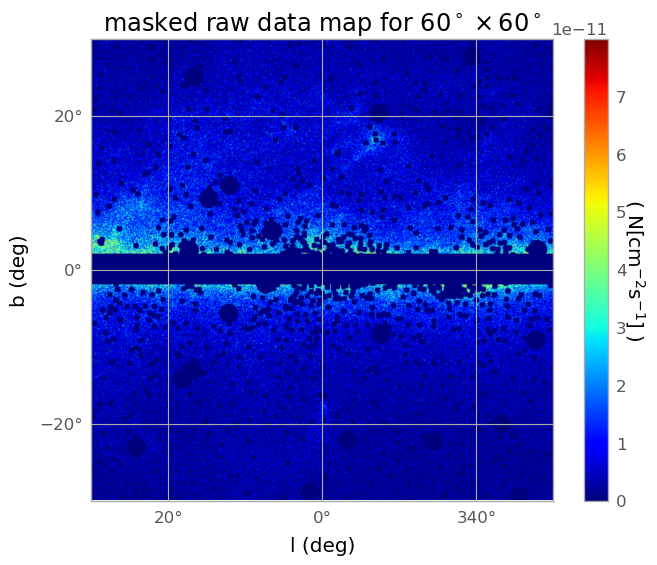

In [22]:
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
import numpy as np

# Open the FITS file and read WCS
src_1 = fits.open(f'./GC_analysis_FL16Y/GC_ccube_17yr{front}_clean.fits')
w = WCS(src_1[0].header).dropaxis(2)

# Define the subset indices for the inner Galactic Center region
# Assuming a 600x600 grid where each pixel = 0.1 degree

#subset = (slice(100, 500), slice(100, 500))  # 100x100 pixels = 10x10 degrees

psc_mask = np.load('./GC_analysis_FL16Y/Model/GC_mask_60x60_definitions_FL16Y.npy')
disk_mask = np.load('./GC_analysis_FL16Y/Model/GC_disk_mask_60x60_definitions.npy')

# Plotting the subset with the correct WCS
fig = plt.figure()
ax = fig.add_subplot(111, projection=w)  # Use the updated WCS
ax.coords[0].set_format_unit('deg', decimal=True, show_decimal_unit=True)
ax.coords[1].set_format_unit('deg', decimal=True, show_decimal_unit=True)

# Plot the data
plot = ax.imshow(
    ( (src_1[0].data/exposure)*psc_mask*disk_mask )[5], 
    origin='lower', 
    cmap='jet', 
    interpolation='gaussian'#,
    #vmin=-1, vmax=1
)

# Add labels, grid, and colorbar
#plt.grid(color='white', ls='solid')
plt.xlabel('l (deg)')  # Galactic longitude
plt.ylabel('b (deg)')  # Galactic latitude
#plt.colorbar(plot)
cbar = plt.colorbar(plot)
cbar.set_label(r'( N[cm$^{-2}$s$^{-1}$] )', rotation=270, labelpad=15)
plt.title(r"masked raw data map for $60^\circ \times 60^\circ$")
plt.show()


In [23]:
def generate_roman_numerals(n):
    """
    Generate a list of Roman numerals from 1 to n.
    """
    roman_map = [
        (1000, 'M'), (900, 'CM'), (500, 'D'), (400, 'CD'),
        (100, 'C'), (90, 'XC'), (50, 'L'), (40, 'XL'),
        (10, 'X'), (9, 'IX'), (5, 'V'), (4, 'IV'), (1, 'I')
    ]

    def to_roman(num):
        roman = ""
        for value, symbol in roman_map:
            while num >= value:
                roman += symbol
                num -= value
        return roman

    return [to_roman(i) for i in range(1, n + 1)]

In [24]:
# Model list: all 80 (Cholis Roman-numeral models) by default.
# Override via MODEL_LIST_OVERRIDE in CONFIG to test a subset.
model_list = generate_roman_numerals(80)
if MODEL_LIST_OVERRIDE:
    model_list = list(MODEL_LIST_OVERRIDE)

# Per-model resume: skip models whose output .dat already exists.
run_list = []
existing_list = []
for model in model_list:
    out_dat = f'./GCE_model_{model}{front}_17yr_cholis.dat'
    if os.path.exists(out_dat):
        existing_list.append(model)
    else:
        run_list.append(model)

print(f'  total models    : {len(model_list)}')
print(f'  already done    : {len(existing_list)}')
print(f'  to run          : {len(run_list)} -> {run_list[:10]}{"..." if len(run_list) > 10 else ""}')

model_list = run_list   # main loop iterates over `model_list`


  total models    : 80
  already done    : 0
  to run          : 80 -> ['I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX', 'X']...


In [25]:
'''
#model='I'
for model in model_list:
    out_dat = f'./GCE_model_{model}{front}_17yr_cholis.dat'
    if os.path.exists(out_dat):
        print(f'[skip] model {model}: {out_dat}')
        continue
    # Define the elements to add
    new_sources = f"""
    <source name="bremss" type="DiffuseSource">
        <spectrum type="ConstantValue">
          <parameter error="0.02899312444" free="1" max="100" min="1" name="Value" scale="1" value="1" />
        </spectrum>
        <spatialModel file="{MAPCUBE_DIR_BREMSS}/bremss_mapcube_model{model}{MAPCUBE_EXT}" type="MapCubeFunction" map_based_integral="true">
          <parameter free="0" max="1000" min="0" name="Normalization" scale="1" value="1" />
        </spatialModel>
      </source>
      <source name="ics" type="DiffuseSource">
        <spectrum type="ConstantValue">
          <parameter error="0.04073673429" free="1" max="100" min="1" name="Value" scale="1" value="1" />
        </spectrum>
        <spatialModel file="{MAPCUBE_DIR_ICS}/ics_mapcube_model{model}{MAPCUBE_EXT}" type="MapCubeFunction" map_based_integral="true">
          <parameter free="0" max="1000" min="0" name="Normalization" scale="1" value="1" />
        </spatialModel>
      </source>
      <source name="pion" type="DiffuseSource">
        <spectrum type="ConstantValue">
          <parameter error="0.02899312444" free="1" max="100" min="1" name="Value" scale="1" value="1" />
        </spectrum>
        <spatialModel file="{MAPCUBE_DIR_PION}/pion_mapcube_model{model}{MAPCUBE_EXT}" type="MapCubeFunction" map_based_integral="true">
          <parameter free="0" max="1000" min="0" name="Normalization" scale="1" value="1" />
        </spatialModel>
      </source>
      <source name="GCE" type="DiffuseSource">
        <spectrum type="BrokenPowerLaw">
        <parameter free="0" max="1000.0" min="0.001" name="Prefactor" scale="1e-11" value="7*3"/>
        <parameter free="0" max="-1.0" min="-5." name="Index1" scale="1.0" value="-1.42"/>
        <parameter free="0" max="3000.0" min="30.0" name="BreakValue" scale="1.0" value="2006"/>
        <parameter free="0" max="-1.0" min="-5." name="Index2" scale="1.0" value="-2.63"/>
    </spectrum>
        <spatialModel file="{WIMP_MAP_PATH}" type="SpatialMap" map_based_integral="true">
        </spatialModel>
      </source>
      <source name="isotropic" type="DiffuseSource">
        <spectrum apply_edisp="true" file="{ISO_SPECTRUM_FILE}" type="FileFunction">
          <parameter free="1" max="10" min="1" name="Normalization" scale="1" value="1" />
        </spectrum>
        <spatialModel type="ConstantValue">
          <parameter free="0" max="10" min="0" name="Value" scale="1" value="1" />
        </spatialModel>
      </source>
      <source name="Fermi_bubble" type="DiffuseSource">
        <spectrum apply_edisp="true" file="{BUBBLE_SPECTRUM_FILE}" type="FileFunction">
          <parameter free="1" max="1e+10" min="0" name="Normalization" scale="1" value="1" />
        </spectrum>
        <spatialModel file="{BUBBLE_TEMPLATE}" type="SpatialMap" map_based_integral="true">
        </spatialModel>
      </source>
    """
    
    # Parse the new sources XML string
    new_sources_tree = ET.ElementTree(ET.fromstring(f"<sources>{new_sources}</sources>"))
    new_sources_root = new_sources_tree.getroot()
    
    # Parse the existing XML file
    tree = ET.parse('./GC_analysis_FL16Y/Model/GC_psc_model_FL16Y.xml')
    root = tree.getroot()
    
    # Append the new sources to the root element of the existing file
    for new_source in new_sources_root:
        root.append(new_source)
    
    # Save the modified XML to a new file
    _xml_path = f'./GC_analysis_FL16Y/Model/GC_model{model}_test.xml'
    if not os.path.exists(_xml_path):
        tree.write(_xml_path, encoding='utf-8', xml_declaration=True)
        print(f'[done] wrote {_xml_path}')
    #Creating total xml model file for srcmap
    
    # Define the elements to add
    new_sources = f"""
    <source name="bremss" type="DiffuseSource">
        <spectrum type="ConstantValue">
          <parameter error="0.02899312444" free="1" max="100" min="1" name="Value" scale="1" value="1" />
        </spectrum>
        <spatialModel file="{MAPCUBE_DIR_BREMSS}/bremss_mapcube_model{model}{MAPCUBE_EXT}" type="MapCubeFunction" map_based_integral="true">
          <parameter free="0" max="1000" min="0" name="Normalization" scale="1" value="1" />
        </spatialModel>
      </source>
      <source name="ics" type="DiffuseSource">
        <spectrum type="ConstantValue">
          <parameter error="0.04073673429" free="1" max="100" min="1" name="Value" scale="1" value="1" />
        </spectrum>
        <spatialModel file="{MAPCUBE_DIR_ICS}/ics_mapcube_model{model}{MAPCUBE_EXT}" type="MapCubeFunction" map_based_integral="true">
          <parameter free="0" max="1000" min="0" name="Normalization" scale="1" value="1" />
        </spatialModel>
      </source>
      <source name="pion" type="DiffuseSource">
        <spectrum type="ConstantValue">
          <parameter error="0.02899312444" free="1" max="100" min="1" name="Value" scale="1" value="1" />
        </spectrum>
        <spatialModel file="{MAPCUBE_DIR_PION}/pion_mapcube_model{model}{MAPCUBE_EXT}" type="MapCubeFunction" map_based_integral="true">
          <parameter free="0" max="1000" min="0" name="Normalization" scale="1" value="1" />
        </spatialModel>
      </source>
      <source name="GCE" type="DiffuseSource">
        <spectrum type="BrokenPowerLaw">
        <parameter free="0" max="1000.0" min="0.001" name="Prefactor" scale="1e-11" value="7*3"/>
        <parameter free="0" max="-1.0" min="-5." name="Index1" scale="1.0" value="-1.42"/>
        <parameter free="0" max="3000.0" min="30.0" name="BreakValue" scale="1.0" value="2006"/>
        <parameter free="0" max="-1.0" min="-5." name="Index2" scale="1.0" value="-2.63"/>
    </spectrum>
        <spatialModel file="{WIMP_MAP_PATH}" type="SpatialMap" map_based_integral="true">
        </spatialModel>
      </source>
      <source name="isotropic" type="DiffuseSource">
        <spectrum apply_edisp="true" file="{ISO_SPECTRUM_FILE}" type="FileFunction">
          <parameter free="1" max="10" min="1" name="Normalization" scale="1" value="1" />
        </spectrum>
        <spatialModel type="ConstantValue">
          <parameter free="0" max="10" min="0" name="Value" scale="1" value="1" />
        </spatialModel>
      </source>
      <source name="Fermi_bubble" type="DiffuseSource">
        <spectrum apply_edisp="true" file="{BUBBLE_SPECTRUM_FILE}" type="FileFunction">
          <parameter free="1" max="1e+10" min="0" name="Normalization" scale="1" value="1" />
        </spectrum>
        <spatialModel file="{BUBBLE_TEMPLATE}" type="SpatialMap" map_based_integral="true">
        </spatialModel>
      </source>
    """
    
    # Parse the new sources XML string
    new_sources_tree = ET.ElementTree(ET.fromstring(f"<sources>{new_sources}</sources>"))
    new_sources_root = new_sources_tree.getroot()
    
    # Parse the existing XML file
    tree = ET.parse('./GC_analysis_FL16Y/Model/empty_model.xml')
    root = tree.getroot()
    
    # Append the new sources to the root element of the existing file
    for new_source in new_sources_root:
        root.append(new_source)
    
    # Save the modified XML to a new file
    _xml_path = f'./GC_analysis_FL16Y/Model/GC_Extended_model{model}_test.xml'
    if not os.path.exists(_xml_path):
        tree.write(_xml_path, encoding='utf-8', xml_declaration=True)
        print(f'[done] wrote {_xml_path}')
    
    
    convol=''
    _srcmap_out = f'./GC_analysis_FL16Y/GC_Extended_srcmap_17yr{front}{"_clean"}_model_{model}{convol}.fits'
    if os.path.exists(_srcmap_out):
        print(f'[skip] gtsrcmaps: {_srcmap_out}')
    else:
        print(f'[run ] gtsrcmaps -> {_srcmap_out}')
        srcMaps = GtApp('gtsrcmaps', 'Likelihood')
        srcMaps['scfile']=SC_FILE
        srcMaps['expcube']=f'./GC_analysis_FL16Y/Allsky_ltcube_17yr{front}{"_clean"}.fits'
        srcMaps['cmap']=f'./GC_analysis_FL16Y/GC_ccube_17yr{front}{"_clean"}.fits'
        srcMaps['bexpmap']=f'./GC_analysis_FL16Y/Allsky_expcube_edge_17yr{front}{"_clean"}.fits'
        srcMaps['srcmdl']=f'./GC_analysis_FL16Y/Model/GC_Extended_model{model}_test.xml'
        srcMaps['outfile']=f'./GC_analysis_FL16Y/GC_Extended_srcmap_17yr{front}{"_clean"}_model_{model}{convol}.fits'
        srcMaps['irfs']=IRFS
        srcMaps['convol']='yes'
        srcMaps['evtype']=evtype_number
        #srcMaps['resample']='no'
        srcMaps.run();
    
    convol='_no_convol'
    _srcmap_out = f'./GC_analysis_FL16Y/GC_Extended_srcmap_17yr{front}{"_clean"}_model_{model}{convol}.fits'
    if os.path.exists(_srcmap_out):
        print(f'[skip] gtsrcmaps: {_srcmap_out}')
    else:
        print(f'[run ] gtsrcmaps -> {_srcmap_out}')
        srcMaps = GtApp('gtsrcmaps', 'Likelihood')
        srcMaps['scfile']=SC_FILE
        srcMaps['expcube']=f'./GC_analysis_FL16Y/Allsky_ltcube_17yr{front}{"_clean"}.fits'
        srcMaps['cmap']=f'./GC_analysis_FL16Y/GC_ccube_17yr{front}{"_clean"}.fits'
        srcMaps['bexpmap']=f'./GC_analysis_FL16Y/Allsky_expcube_edge_17yr{front}{"_clean"}.fits'
        srcMaps['srcmdl']=f'./GC_analysis_FL16Y/Model/GC_Extended_model{model}_test.xml'
        srcMaps['outfile']=f'./GC_analysis_FL16Y/GC_Extended_srcmap_17yr{front}{"_clean"}_model_{model}{convol}.fits'
        srcMaps['irfs']=IRFS
        srcMaps['convol']='no'
        srcMaps['evtype']=evtype_number
        #srcMaps['resample']='no'
        srcMaps.run();
    
    for component in ['bremss', 'ics', 'pion']:
        # Define the elements to add
        new_sources = f"""
        <source name="{component}" type="DiffuseSource">
            <spectrum type="ConstantValue">
              <parameter error="0.02899312444" free="1" max="100" min="1" name="Value" scale="1" value="1" />
            </spectrum>
            <spatialModel file="{MAPCUBE_DIR_PION}/{component}_mapcube_model{model}{MAPCUBE_EXT}" type="MapCubeFunction" map_based_integral="true">
              <parameter free="0" max="1000" min="0" name="Normalization" scale="1" value="1" />
            </spatialModel>
          </source>
        """
        
        # Parse the new sources XML string
        new_sources_tree = ET.ElementTree(ET.fromstring(f"<sources>{new_sources}</sources>"))
        new_sources_root = new_sources_tree.getroot()
        
        # Parse the existing XML file
        tree = ET.parse('./GC_analysis_FL16Y/Model/empty_model.xml')
        root = tree.getroot()
        
        # Append the new sources to the root element of the existing file
        for new_source in new_sources_root:
            root.append(new_source)
        
        # Save the modified XML to a new file
        _xml_path = f'./GC_analysis_FL16Y/Model/GC_{component}_model{model}_test.xml'
        if not os.path.exists(_xml_path):
            tree.write(_xml_path, encoding='utf-8', xml_declaration=True)
    
    
    convol=''
    for component in ['pion', 'bremss', 'ics']:
        _gtm_out = f'./GC_analysis_FL16Y/GC_{component}_model{model}_17yr{front}_clean{convol}.fits'
        if os.path.exists(_gtm_out):
            print(f'[skip] gtmodel: {_gtm_out}')
        else:
            print(f'[run ] gtmodel -> {_gtm_out}')
            gtmodel = GtApp('gtmodel', 'Likelihood')
            gtmodel['irfs']=IRFS
            gtmodel['outtype']='ccube'
            gtmodel['srcmdl']=f'./GC_analysis_FL16Y/Model/GC_{component}_model{model}_test.xml'
            gtmodel['outfile']=f'./GC_analysis_FL16Y/GC_{component}_model{model}_17yr{front}_clean{convol}.fits'
            gtmodel['expcube']=f'./GC_analysis_FL16Y/Allsky_ltcube_17yr{front}{"_clean"}.fits'
            gtmodel['bexpmap']=f'./GC_analysis_FL16Y/Allsky_expcube_edge_17yr{front}{"_clean"}.fits'
            gtmodel['convol']='yes'
            #gtmodel['resample']='no'
            gtmodel['evtype']=evtype_number
            gtmodel['srcmaps']=f'./GC_analysis_FL16Y/GC_Extended_srcmap_17yr{front}{"_clean"}_model_{model}{convol}.fits'
            gtmodel.run()
    
    
    convol='_no_convol'
    for component in ['pion', 'bremss', 'ics']:
        _gtm_out = f'./GC_analysis_FL16Y/GC_{component}_model{model}_17yr{front}_clean{convol}.fits'
        if os.path.exists(_gtm_out):
            print(f'[skip] gtmodel: {_gtm_out}')
        else:
            print(f'[run ] gtmodel -> {_gtm_out}')
            gtmodel = GtApp('gtmodel', 'Likelihood')
            gtmodel['irfs']=IRFS
            gtmodel['outtype']='ccube'
            gtmodel['srcmdl']=f'./GC_analysis_FL16Y/Model/GC_{component}_model{model}_test.xml'
            gtmodel['outfile']=f'./GC_analysis_FL16Y/GC_{component}_model{model}_17yr{front}_clean{convol}.fits'
            gtmodel['expcube']=f'./GC_analysis_FL16Y/Allsky_ltcube_17yr{front}{"_clean"}.fits'
            gtmodel['bexpmap']=f'./GC_analysis_FL16Y/Allsky_expcube_edge_17yr{front}{"_clean"}.fits'
            gtmodel['convol']='no'
            #gtmodel['resample']='no'
            gtmodel['evtype']=evtype_number
            gtmodel['srcmaps']=f'./GC_analysis_FL16Y/GC_Extended_srcmap_17yr{front}{"_clean"}_model_{model}{convol}.fits'
            gtmodel.run()




    # ============================================================
    # GCE / Fermi_bubble / isotropic prep
    # (was in 16yr cell 36 / v4 cell 43 — incorrectly disabled in v3
    # under "duplicated by main loop"; in fact it produces 6 files
    # the active emcee code reads. Restored in v10 with skip-if-exists.)
    # ============================================================

    # ---- Build per-source XML files (one source appended to empty_model.xml) ----
    _src_specs = {
        'GCE': f"""
      <source name="GCE" type="DiffuseSource">
        <spectrum type="BrokenPowerLaw">
        <parameter free="0" max="1000.0" min="0.001" name="Prefactor" scale="1e-11" value="7*3"/>
        <parameter free="0" max="-1.0" min="-5." name="Index1" scale="1.0" value="-1.42"/>
        <parameter free="0" max="3000.0" min="30.0" name="BreakValue" scale="1.0" value="2006"/>
        <parameter free="0" max="-1.0" min="-5." name="Index2" scale="1.0" value="-2.63"/>
        </spectrum>
        <spatialModel file="{WIMP_MAP_PATH}" type="SpatialMap" map_based_integral="true">
        </spatialModel>
      </source>
""",
        'isotropic': f"""
      <source name="isotropic" type="DiffuseSource">
        <spectrum apply_edisp="true" file="{ISO_SPECTRUM_FILE}" type="FileFunction">
          <parameter free="1" max="10" min="1" name="Normalization" scale="1" value="1" />
        </spectrum>
        <spatialModel type="ConstantValue">
          <parameter free="0" max="10" min="0" name="Value" scale="1" value="1" />
        </spatialModel>
      </source>
""",
        'fermi_bubble': f"""
      <source name="Fermi_bubble" type="DiffuseSource">
        <spectrum apply_edisp="true" file="{BUBBLE_SPECTRUM_FILE}" type="FileFunction">
          <parameter free="1" max="1e+10" min="0" name="Normalization" scale="1" value="1" />
        </spectrum>
        <spatialModel file="{BUBBLE_TEMPLATE}" type="SpatialMap" map_based_integral="true">
        </spatialModel>
      </source>
""",
    }
    for _src_name, _src_xml in _src_specs.items():
        _src_model_xml = f'./GC_analysis_FL16Y/Model/GC_{_src_name}_model.xml'
        if os.path.exists(_src_model_xml):
            continue
        _new_sources_root = ET.fromstring(f"<sources>{_src_xml}</sources>")
        _tree = ET.parse('./GC_analysis_FL16Y/Model/empty_model.xml')
        _root = _tree.getroot()
        for _new_src in _new_sources_root:
            _root.append(_new_src)
        _tree.write(_src_model_xml, encoding='utf-8', xml_declaration=True)
        print(f'[done] wrote {_src_model_xml}')

    # ---- gtmodel × 2 (convol='yes' / convol='no') over [GCE, fermi_bubble, isotropic] ----
    for _convol_setting, _convol_suffix in [('yes', ''), ('no', '_no_convol')]:
        # The srcmaps input is per-model (uses {model}{convol}.fits from gtsrcmaps);
        # the outfile is NOT per-model (model-independent template).
        _src_srcmap = f'./GC_analysis_FL16Y/GC_Extended_srcmap_17yr{front}{"_clean"}_model_{model}{_convol_suffix}.fits'
        for _comp_name in ['GCE', 'fermi_bubble', 'isotropic']:
            _comp_out = f'./GC_analysis_FL16Y/GC_{_comp_name}_model_17yr{front}_clean{_convol_suffix}.fits'
            if os.path.exists(_comp_out):
                print(f'[skip] gtmodel ({_comp_name}, convol={_convol_setting}): {_comp_out}')
                continue
            print(f'[run ] gtmodel ({_comp_name}, convol={_convol_setting}) -> {_comp_out}')
            _gtm = GtApp('gtmodel', 'Likelihood')
            _gtm['irfs']      = IRFS
            _gtm['outtype']   = 'ccube'
            _gtm['srcmdl']    = f'./GC_analysis_FL16Y/Model/GC_{_comp_name}_model.xml'
            _gtm['outfile']   = _comp_out
            _gtm['expcube']   = f'./GC_analysis_FL16Y/Allsky_ltcube_17yr{front}{"_clean"}.fits'
            _gtm['bexpmap']   = f'./GC_analysis_FL16Y/Allsky_expcube_edge_17yr{front}{"_clean"}.fits'
            _gtm['convol']    = _convol_setting
            _gtm['evtype']    = evtype_number
            _gtm['srcmaps']   = _src_srcmap
            _gtm.run()

    ## Emcee running part
    
    def roi_solid_angle(delta_l_deg, delta_b_deg, b_deg):
        # Convert degrees to radians
        delta_l_rad = np.radians(delta_l_deg)
        delta_b_rad = np.radians(delta_b_deg)
        b_rad = np.radians(b_deg)
        
        # Calculate solid angle in steradians
        solid_angle = delta_l_rad * delta_b_rad * np.cos(b_rad)
        return solid_angle
    
    raw_map=fits.open(f'./GC_analysis_FL16Y/GC_ccube_17yr{front}_clean.fits')
    w=WCS(raw_map[0].header).dropaxis(2)
    # Define the dimensions of the numpy array
    width, height = np.shape(raw_map[0].data[0])
    
    # Create the counts map
    steradian_per_pixel=np.zeros([width, height])
    
    for i in range(0, height, 1):
        for j in range(0, width, 1):
            l, b = w.wcs_pix2world(j, i, 0) #x-axis array - b, y-axis array - l
            steradian_per_pixel[i, j] = roi_solid_angle(0.1, 0.1, b)
    
    # Revision :: Aug 11, 2024
    disk_mask=np.load('./GC_analysis_FL16Y/Model/GC_disk_mask_60x60_definitions.npy')[100:500, 100:500]
    psc_mask=np.load('./GC_analysis_FL16Y/Model/GC_mask_60x60_definitions_FL16Y.npy')[:, 100:500, 100:500]
    
    # [17yr] front comes from CONFIG cell — kept here for reference: front='_front_back'
    convol='_no_convol'
    
    E_bounds=fits.open(f'./GC_analysis_FL16Y/GC_ccube_17yr{front}_clean.fits')[1].data
    
    
    E=np.zeros(len(E_bounds))
    for i in range(0, len(E_bounds), 1):
        E[i] = np.sqrt(E_bounds[i][2]*E_bounds[i][1]*1e-6)*1e-3
    
    delta_E=np.zeros(len(E_bounds))
    for i in range(0, len(E_bounds), 1):
        delta_E[i] = (E_bounds[i][2] - E_bounds[i][1])*1e-6
    
    exp_cube = fits.open(f'./GC_analysis_FL16Y/GC_expcube_center_17yr{front}_clean.fits')[0].data[:, 100:500, 100:500]*steradian_per_pixel[100:500, 100:500]
    
    
    
    file_name=f'./GC_analysis_FL16Y/GC_pion_model{model}_17yr{front}_clean_no_convol.fits'
    pion=np.zeros(len(E_bounds))
    for i in range(0, len(E_bounds), 1):
        a=exp_cube[i]
        pion[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/a) )/np.sum(disk_mask)
    
    file_name=f'./GC_analysis_FL16Y/GC_bremss_model{model}_17yr{front}_clean_no_convol.fits'
    bremss=np.zeros(len(E_bounds))
    for i in range(0, len(E_bounds), 1):
        a=exp_cube[i]
        bremss[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/a) )/np.sum(disk_mask)
        
    file_name=f'./GC_analysis_FL16Y/GC_ics_model{model}_17yr{front}_clean_no_convol.fits'
    ics=np.zeros(len(E_bounds))
    for i in range(0, len(E_bounds), 1):
        a=exp_cube[i]
        ics[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/a) )/np.sum(disk_mask)
        
    file_name=f'./GC_analysis_FL16Y/GC_GCE_model_17yr{front}_clean_no_convol.fits'
    GCE=np.zeros(len(E_bounds))
    for i in range(0, len(E_bounds), 1):
        a=exp_cube[i]
        GCE[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/exp_cube[i]) )/np.sum(disk_mask)
    
    
    file_name=f'./GC_analysis_FL16Y/GC_fermi_bubble_model_17yr{front}_clean_no_convol.fits'
    bubble=np.zeros(len(E_bounds))
    for i in range(0, len(E_bounds), 1):
        a=exp_cube[i]
        bubble[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/a) )/np.sum(disk_mask)
        
    file_name=f'./GC_analysis_FL16Y/GC_isotropic_model_17yr{front}_clean_no_convol.fits'
    isotropic=np.zeros(len(E_bounds))
    for i in range(0, len(E_bounds), 1):
        a=exp_cube[i]
        isotropic[i] = np.sum( disk_mask*(fits.open(file_name)[0].data[i][100:500, 100:500]/a) )/np.sum(disk_mask)
        
    counts_per_exp=np.zeros(len(E_bounds))
    i=0
    for i in range(0, len(E_bounds), 1):
        a=exp_cube[i]
        counts_per_exp[i]=np.sum( disk_mask*( (fits.open(f'./GC_analysis_FL16Y/GC_ccube_17yr{front}_clean.fits')[0].data[i][100:500, 100:500]) /a) )/np.sum(disk_mask)
    
    counts_per_exp_err=np.zeros(len(E_bounds))
    i=0
    for i in range(0, len(E_bounds), 1):
        counts_per_exp_err[i]= np.sqrt( np.sum( ( (np.sqrt(disk_mask*fits.open(f'./GC_analysis_FL16Y/GC_ccube_17yr{front}_clean.fits')[0].data[i][100:500, 100:500]) /exp_cube[i] )**2)) )/np.sum(disk_mask)
        #counts_per_exp_err[i]=  np.sqrt(np.sum(disk_mask*fits.open(f'./GC_analysis_FL16Y/GC_all_time_60x60_ccube{front}_17yr.fits')[0].data[i][100:500, 100:500]))/np.sum(disk_mask*exp_cube[i]) 
    
        
    
    def log_factorial(O):
        """v12: vectorized log(O!) via gammaln(O+1) - ~1000x faster than the Python-loop version."""
        return gammaln(np.asarray(O, dtype=float) + 1.0)
    #Constraints interpolated function
    #Contains constraints for bubble and isotropic as well
    #For isotropic, from https://arxiv.org/pdf/1410.3696.pdf Table 3
    #Correcting bubble template given from https://arxiv.org/pdf/1407.7905, Table 2
    
    bubble_constraints=np.loadtxt('./GC_analysis_FL16Y/Model/bubble_constraints.txt')
    bubble_constraints_energy=bubble_constraints[0:, 0]
    bubble_constraints_flux=bubble_constraints[0:, 1]
    bubble_constraints_lower_error=bubble_constraints[0:, 2]
    bubble_constraints_upper_error=bubble_constraints[0:, 3]
    
    bubble_fluxint = interp1d((bubble_constraints_energy), (bubble_constraints_flux), fill_value='extrapolate', kind='quadratic')
    bubble_lower_errint = interp1d((bubble_constraints_energy), (bubble_constraints_lower_error), fill_value='extrapolate', kind='quadratic')
    bubble_upper_errint = interp1d((bubble_constraints_energy), (bubble_constraints_upper_error), fill_value='extrapolate', kind='quadratic')
    
    bubble_flux_data=bubble_fluxint((E))
    bubble_lower_error_data=bubble_lower_errint((E))
    bubble_upper_error_data=bubble_upper_errint((E))
    
    
    iso_constraints=np.loadtxt('./GC_analysis_FL16Y/Model/iso_constraints_full_err.txt')
    #iso_constraints=np.loadtxt('./GC_analysis_FL16Y/Model/egb_constraints_full_err.txt')
    
    iso_constraints_energy=iso_constraints[0:, 0]
    iso_constraints_flux=iso_constraints[0:, 1]
    iso_constraints_low_err=iso_constraints[0:, 2]
    iso_constraints_upp_err=iso_constraints[0:, 3]
    
    isotropic_fluxint=interp1d(iso_constraints_energy, iso_constraints_flux, fill_value="extrapolate", kind='quadratic')
    isotropic_lower_errint=interp1d(iso_constraints_energy, iso_constraints_low_err, fill_value="extrapolate", kind='quadratic')    
    isotropic_upper_errint=interp1d(iso_constraints_energy, iso_constraints_upp_err, fill_value="extrapolate", kind='quadratic')  
    
    isotropic_flux_data=((E)**2)*(isotropic_fluxint((E)))
    isotropic_lower_error_data=((E)**2)*(isotropic_lower_errint((E)))
    isotropic_upper_error_data=((E)**2)*(isotropic_upper_errint((E)))
    
    # [17yr] front comes from CONFIG cell — kept here for reference: front='_front_back'
    class Likelihood:
        def __init__(self, model, energy_bin):
            self.model=model
            self.energy_bin=energy_bin
            self.data=fits.open(f'./GC_analysis_FL16Y/GC_ccube_17yr{front}_clean.fits')[0].data[self.energy_bin, 100:500, 100:500]
            self.pion_bremss=fits.open(f'./GC_analysis_FL16Y/GC_pion_model{model}_17yr{front}_clean.fits')[0].data[self.energy_bin, 100:500, 100:500] + fits.open(f'./GC_analysis_FL16Y/GC_bremss_model{model}_17yr{front}_clean.fits')[0].data[self.energy_bin, 100:500, 100:500]  
            self.ics=fits.open(f'./GC_analysis_FL16Y/GC_ics_model{model}_17yr{front}_clean.fits')[0].data[self.energy_bin, 100:500, 100:500]
            self.GCE=fits.open(f'./GC_analysis_FL16Y/GC_GCE_model_17yr{front}_clean.fits')[0].data[self.energy_bin, 100:500, 100:500]
            self.bubble=fits.open(f'./GC_analysis_FL16Y/GC_fermi_bubble_model_17yr{front}_clean.fits')[0].data[self.energy_bin, 100:500, 100:500]
            self.iso=fits.open(f'./GC_analysis_FL16Y/GC_isotropic_model_17yr{front}_clean.fits')[0].data[self.energy_bin, 100:500, 100:500]
            # v12: cache no_convol versions for SED chi2 terms
            self.iso_no_convol    = fits.open(f'./GC_analysis_FL16Y/GC_isotropic_model_17yr{front}_clean_no_convol.fits')[0].data[self.energy_bin, 100:500, 100:500]
            self.bubble_no_convol = fits.open(f'./GC_analysis_FL16Y/GC_fermi_bubble_model_17yr{front}_clean_no_convol.fits')[0].data[self.energy_bin, 100:500, 100:500]
            E_bounds=fits.open(f'./GC_analysis_FL16Y/GC_ccube_17yr{front}_clean.fits')[1].data
    
            E=np.zeros(len(E_bounds))
            for i in range(0, len(E_bounds), 1):
                E[i] = np.sqrt(E_bounds[i][2]*E_bounds[i][1]*1e-6)*1e-3
            self.E = E
            delta_E=np.zeros(len(E_bounds))
            for i in range(0, len(E_bounds), 1):
                delta_E[i] = (E_bounds[i][2] - E_bounds[i][1])*1e-6
            self.delta_E = delta_E
            self.exp_cube = (fits.open(f'./GC_analysis_FL16Y/GC_expcube_center_17yr{front}_clean.fits')[0].data[self.energy_bin]*steradian_per_pixel)[100:500, 100:500]
    
            
            psc_mask=np.load('./GC_analysis_FL16Y/Model/GC_mask_60x60_definitions_FL16Y.npy')[self.energy_bin, 100:500, 100:500]
    
            disk_mask=np.load('./GC_analysis_FL16Y/Model/GC_disk_mask_60x60_definitions.npy')[100:500, 100:500]
            full_mask=psc_mask*disk_mask
            self.disk_mask=disk_mask
            self.full_mask=full_mask
            # v12: precompute log(O!) on masked observed data once per bin
            _obs_masked = self.data[self.full_mask == 1].astype(float)
            self.observed_log_factorial_masked = log_factorial(_obs_masked)
        def likelihood_constrained(self, parameter_set):
            #####################################
            pion_bremss_param=parameter_set[0]
            ics_param=parameter_set[1]
            GCE_param=parameter_set[2]
            bubble_param=parameter_set[3]
            isotropic_param=parameter_set[4]
            ######################################
            expected_pixel= (pion_bremss_param)*self.pion_bremss + (ics_param)*self.ics + (GCE_param)*self.GCE + (isotropic_param)*self.iso + (bubble_param)*self.bubble   
            observed_pixel = self.data
    
            observed_pixel = observed_pixel[self.full_mask == 1]
            expected_pixel = expected_pixel[self.full_mask == 1]
    
            
            if (expected_pixel < 0).any():
                return np.inf
                
            #expected_pixel[expected_pixel == 0.0] += 1e-20
            
            observed_log_expected=observed_pixel*np.log(expected_pixel)
            #nan_index = np.where(np.isnan(observed_log_expected))
            #observed_log_expected[nan_index] = 0
            lhd=2*( expected_pixel - observed_log_expected + self.observed_log_factorial_masked )
    
            
            file_name=f'./GC_analysis_FL16Y/GC_isotropic_model_17yr{front}_clean_no_convol.fits'
            _cached_no_convol = self.iso_no_convol
            #isotropic = np.sum( self.full_mask*(fits.open(file_name)[0].data[self.energy_bin]/self.exp_cube) )*isotropic_param/np.sum(self.full_mask)
            #isotropic = np.sum( self.full_mask*(fits.open(file_name)[0].data[self.energy_bin]) )*isotropic_param/np.sum(self.full_mask*self.exp_cube)
            #isotropic = np.sum( self.full_mask*(fits.open(file_name)[0].data[self.energy_bin])/self.exp_cube )*isotropic_param/np.sum(self.full_mask)
            isotropic = np.sum( self.full_mask*(_cached_no_convol)/self.exp_cube )*isotropic_param/np.sum(self.full_mask)
            #isotropic = np.sum( (fits.open(file_name)[0].data[self.energy_bin])/self.exp_cube )*isotropic_param/np.sum(600*600)
    
            isotropic_sed = (self.E[self.energy_bin]**2)*isotropic/(self.delta_E[self.energy_bin])
    
    
            file_name=f'./GC_analysis_FL16Y/GC_fermi_bubble_model_17yr{front}_clean_no_convol.fits'
            _cached_no_convol = self.bubble_no_convol
            #bubble = np.sum( self.full_mask*(fits.open(file_name)[0].data[self.energy_bin]/self.exp_cube) )*bubble_param/np.sum(self.full_mask)
            #bubble = np.sum( self.full_mask*(fits.open(file_name)[0].data[self.energy_bin]) )*bubble_param/np.sum(self.full_mask*self.exp_cube)
            #bubble = np.sum( self.full_mask*(fits.open(file_name)[0].data[self.energy_bin])/self.exp_cube )*bubble_param/np.sum(self.full_mask)
            bubble = np.sum( self.full_mask*(_cached_no_convol)/self.exp_cube )*bubble_param/np.sum(self.full_mask)
            #bubble = np.sum( (fits.open(file_name)[0].data[self.energy_bin])/self.exp_cube )*bubble_param/np.sum(600*600)
            bubble_sed = (self.E[self.energy_bin]**2)*bubble/(self.delta_E[self.energy_bin])
    
            larger_error=max([bubble_upper_error_data[self.energy_bin], bubble_lower_error_data[self.energy_bin]])
            if bubble_flux_data[self.energy_bin] < bubble_sed:
                chi2_bubble = ((bubble_sed - bubble_flux_data[self.energy_bin])/bubble_upper_error_data[self.energy_bin])**2
            if bubble_flux_data[self.energy_bin] > bubble_sed:
                chi2_bubble = ((bubble_sed - bubble_flux_data[self.energy_bin])/bubble_lower_error_data[self.energy_bin])**2
            if bubble_flux_data[self.energy_bin] == bubble_sed:
                chi2_bubble = ((bubble_sed - bubble_flux_data[self.energy_bin])/larger_error)**2
    
    
            isotropic_larger_error = max([isotropic_lower_error_data[self.energy_bin],
                                          isotropic_upper_error_data[self.energy_bin]])
            if isotropic_flux_data[self.energy_bin] < isotropic_sed:
                # model > data → upper_error 사용
                chi2_isotropic = ((isotropic_flux_data[self.energy_bin] - isotropic_sed)
                                  / isotropic_upper_error_data[self.energy_bin])**2
            elif isotropic_flux_data[self.energy_bin] > isotropic_sed:
                # model < data → lower_error 사용 (+ [i] → [self.energy_bin])
                chi2_isotropic = ((isotropic_flux_data[self.energy_bin] - isotropic_sed)
                                  / isotropic_lower_error_data[self.energy_bin])**2
            else:
                chi2_isotropic = ((isotropic_flux_data[self.energy_bin] - isotropic_sed)
                                  / isotropic_larger_error)**2
    
    
    
    # Define your likelihood function
    def log_likelihood(params, energy_bin):
        # Assuming your Likelihood class and method are correctly set up
        return -(1/2)*Likelihood(model, energy_bin).likelihood_constrained(params)  # log likelihood -> Need to maximize
    
    # Define the prior function with parameter limits
    def log_prior(params):
        limits = [
            (0, np.inf), (0, np.inf), (0, np.inf), (0, np.inf), (0, np.inf)
            #(0, 2), (0, 2), (-5, 5), (0.09, 0.11), (0, 5)
            #(-3, 3),  # Bounds for param1
            #(-3, 3),  # Bounds for param2
            #(-5, 5),  # Bounds for param3
            #(-3, 3),  # Bounds for param4
            #(-3, 3)   # Bounds for param5
        ]
        
        for i, (lower, upper) in enumerate(limits):
            if not (lower <= params[i] <= upper):
                return -np.inf  # Return negative infinity if outside bounds
        return 0.0  # Return zero if all parameters are within bounds
    
    # Define the log probability function
    def log_probability(params, energy_bin):
        lp = log_prior(params)
        if not np.isfinite(lp):
            return -np.inf
        return lp + log_likelihood(params, energy_bin)  # Maximize this
        #return log_likelihood(params, energy_bin)
    
    def run_mcmc_for_bin(energy_bin):  
        ndim = 5
        nwalkers = 100
        nsteps = 1000
        burn_in_steps = 400
        start_time=time.time()
        print(energy_bin)
        with Pool() as pool:
            #np.random.seed(100100)#
            #initial_params = np.random.uniform(0, 1, [nwalkers, ndim])
            #initial_params = np.vstack([np.random.uniform(0, 1, [nwalkers]), np.random.uniform(0, 1, [nwalkers]), np.random.uniform(9, 11, [nwalkers]), np.random.uniform(0, 1, [nwalkers]), np.random.uniform(2, 3, [nwalkers])]).T
            initial_params = np.vstack([np.random.uniform(0, 3, [nwalkers]), np.random.uniform(0, 3, [nwalkers]), np.random.uniform(0, 3, [nwalkers]), np.random.uniform(0, 10, [nwalkers]), np.random.uniform(0, 10, [nwalkers])]).T
            #initial_params = np.abs(np.ones(5) + np.random.randn(nwalkers, ndim))
            #initial_params = np.vstack([np.random.uniform(-5, 5, [nwalkers]), np.random.uniform(-5, 5, [nwalkers]), np.random.uniform(-5, 5, [nwalkers]), np.random.uniform(-5, 5, [nwalkers]), np.random.uniform(-5, 5, [nwalkers])]).T
            #initial_params = np.abs(np.ones(5) + 0.1*np.random.randn(nwalkers, ndim))
            pos = initial_params
    
            from emcee.moves import DEMove, KDEMove
            
            sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(energy_bin,), pool=pool)#, moves=[(DEMove(), 0.7), (KDEMove(), 0.3)])
            #for iteration in range(10):    
            print("Running production...")
            pos, prob, state = sampler.run_mcmc(pos, nsteps, progress=True)
            #sampler.run_mcmc(pos, nsteps, progress=True)
            
            max_pos = pos[np.argmax(prob)]
            fitted_param = max_pos
            #max_lhd = np.argmax(prob)
    
      
            
            log_prob_samples = sampler.get_log_prob(discard=burn_in_steps, flat=True)
    
            max_prob_index = np.argmax(log_prob_samples)
            max_lhd = log_prob_samples[max_prob_index]
    
            best_fit_params = sampler.get_chain(discard=burn_in_steps, flat=True)[max_prob_index]        
    
            fitted_param = best_fit_params
            
            flat_samples = sampler.get_chain(discard=burn_in_steps, flat=True)
    
            lower_1sigma = np.percentile(flat_samples, 16, axis=0)
            upper_1sigma = np.percentile(flat_samples, 84, axis=0)
    
            #for i in range(ndim):
            # Calculate the 16th, 50th, and 84th percentiles for the i-th parameter
                #mcmc = np.percentile(flat_samples[:, i], [50])
                #fitted_param[i] = mcmc[0]
                #print(mcmc[0])
    
            print(max_pos)#, best_fit_params, fitted_param)
    
            
    
            #fitted_param = best_fit_params
            
            # Get only the samples from the current iteration
            samples = sampler.get_chain(discard=burn_in_steps, thin=1, flat=False)
            current_samples = samples[-nsteps:]  # Get only the last `nsteps` samples
        
            print("Max position:", fitted_param)
            # Trace Plot for Each Walker and Parameter
            fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
            for i in range(ndim):
                ax = axes[i]
                for walker in range(nwalkers):
                    ax.plot(current_samples[:, walker, i], alpha=0.3)  # Plot each walker separately
                ax.set_xlim(0, nsteps)
                ax.set_ylim(-3, 20)
                ax.set_ylabel(f"param{i+1}")
                ax.yaxis.set_label_coords(-0.1, 0.5)
        
            axes[-1].set_xlabel("step number")
            plt.suptitle(f"Trace Plot for Each Walker after iteration")
            plt.show()
        
            # Final Corner Plot with ChainConsumer
            flat_samples = sampler.get_chain(discard=burn_in_steps, thin=1, flat=True)  # Flatten for ChainConsumer
            c = ChainConsumer()
            c.add_chain(Chain(samples=pd.DataFrame(flat_samples, columns=["param1", "param2", "param3", "param4", "param5"]), name='MCMC'))
            fig = c.plotter.plot(figsize=(6, 6))
            axes=fig.axes
            #for ax in axes:
            #    ax.set_xlim(-1, 6)
            #    ax.set_ylim(-1, 6)
            plt.show()
            print("std", np.std(flat_samples, axis=0, ddof=1))
        end_time=time.time()
        #print(f"{np.round((end_time-start_time)/(60*60), 5)}hours")
        print(fitted_param, np.median(flat_samples, axis=0))
        return fitted_param.T, np.median(flat_samples, axis=0).T, np.std(flat_samples, axis=0, ddof=1).T, max_lhd, upper_1sigma, lower_1sigma
        #return np.median(samples, axis=0), np.std(samples, axis=0)
    
    n=len(E)
    fitted_params=np.ones([n*5])
    fitted_params_median=np.ones([n*5])
    fitted_params_std = np.zeros([n*5])
    max_likelihood = np.zeros([n])
    
    fitted_params_upper = np.zeros([n*5])
    fitted_params_lower = np.zeros([n*5])
    for i in range(0, n, 1):
        max_value, median_value, std_value, maximum_value, upper_value, lower_value = run_mcmc_for_bin(i)
        fitted_params[n*0:n*1][i] = max_value[0]
        fitted_params[n*1:n*2][i] = max_value[1]
        fitted_params[n*2:n*3][i] = max_value[2]
        fitted_params[n*3:n*4][i] = max_value[3]
        fitted_params[n*4:n*5][i] = max_value[4]
    
        fitted_params_std[n*0:n*1][i] = std_value[0]
        fitted_params_std[n*1:n*2][i] = std_value[1]
        fitted_params_std[n*2:n*3][i] = std_value[2]
        fitted_params_std[n*3:n*4][i] = std_value[3]
        fitted_params_std[n*4:n*5][i] = std_value[4]
    
        fitted_params_median[n*0:n*1][i] = median_value[0]
        fitted_params_median[n*1:n*2][i] = median_value[1]
        fitted_params_median[n*2:n*3][i] = median_value[2]
        fitted_params_median[n*3:n*4][i] = median_value[3]
        fitted_params_median[n*4:n*5][i] = median_value[4]
    
        fitted_params_upper[n*0:n*1][i] = upper_value[0]
        fitted_params_upper[n*1:n*2][i] = upper_value[1]
        fitted_params_upper[n*2:n*3][i] = upper_value[2]
        fitted_params_upper[n*3:n*4][i] = upper_value[3]
        fitted_params_upper[n*4:n*5][i] = upper_value[4]
    
    
        fitted_params_lower[n*0:n*1][i] = lower_value[0]
        fitted_params_lower[n*1:n*2][i] = lower_value[1]
        fitted_params_lower[n*2:n*3][i] = lower_value[2]
        fitted_params_lower[n*3:n*4][i] = lower_value[3]
        fitted_params_lower[n*4:n*5][i] = lower_value[4]
    
    
        max_likelihood[i] = maximum_value
        
        plt.style.use('default')
        ax=plt.subplot()
        
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('E [GeV]')
        ax.set_ylabel(r'$E^2 \frac{dN}{dE}$[GeV$cm^{-2}$$s^{-1} sr^{-1}$]')
        
        ax.set_ylim(1e-8, 1e-4)
        ax.set_xlim(0.3, 500)
        
        ax.tick_params(axis='y', which='both', direction='in', left=True)
        ax.tick_params(axis='x', which='both', direction='in', bottom=True)
        ax.minorticks_on()
        ax.grid(True, which='Major', linestyle='-', linewidth=0.5)
        
        fitted=fitted_params#fitted_params
        fitted_errors=fitted_params_std
        #sr=0.4288213187542626#0.214411*2
        sr=1
        #sr=0.4387
        #sr=0.4776
    
        ax.errorbar(E, counts_per_exp*(E**2)/(delta_E*sr) , yerr=counts_per_exp_err*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='Raw_data')
        
        
        
        
        ax.errorbar(E, fitted[n*0:n*1]*(pion+bremss)*(E**2)/(delta_E*sr), yerr=fitted_errors[n*0:n*1]*(pion+bremss)*(E**2)/(delta_E*sr), linestyle='dotted', marker='.', elinewidth=2, capsize=4, capthick=2, label='pion+bremss', color='red')
        ax.errorbar(E, fitted[n*1:n*2]*(ics)*(E**2)/(delta_E*sr), yerr=fitted_errors[n*1:n*2]*(ics)*(E**2)/(delta_E*sr), linestyle='dashdot', marker='.', elinewidth=2, capsize=4, capthick=2, label='ics', color='blue')
        
        ax.plot(E, (pion+bremss)*(E**2)/(delta_E*sr), linestyle='solid', label='pion+bremss', color='red')
        ax.plot(E, (ics)*(E**2)/(delta_E*sr), linestyle='solid', label='ics', color='blue')
        
        
        
        ax.errorbar(E,  fitted[n*2:n*3]*(GCE)*(E**2)/(delta_E*sr), yerr=np.sqrt((fitted_errors[n*2:n*3]*GCE)**2)*(E**2)/(delta_E*sr), alpha=0.1, linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='GCE', color='black')
        
        
        
        ax.errorbar(E, fitted[n*3:n*4]*(bubble)*(E**2)/(delta_E*sr),yerr=fitted_errors[n*3:n*4]*(bubble)*(E**2)/(delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='bubble', color='purple')
        
        ax.errorbar(E, fitted[n*4:n*5]*(isotropic)*(E**2)/(delta_E*sr),yerr=fitted_errors[n*4:n*5]*(isotropic)*(E**2)/(delta_E*sr), linestyle='dashed', marker='.', elinewidth=2, capsize=4, capthick=2, label='isotropic', color='green')
        summed = fitted[n*0:n*1]*(pion+bremss) + fitted[n*1:n*2]*(ics) + fitted[n*2:n*3]*(GCE) + fitted[n*3:n*4]*(bubble) + fitted[n*4:n*5]*(isotropic)
    
        ax.plot(E, (E**2)*summed/(delta_E*sr), label='summed')
        
        
        plt.show()
    
        print((fitted[n*2:n*3]*(GCE)*(E**2)/(delta_E*sr))[i])
        print(((fitted_params_upper[n*2:n*3] - fitted[n*2:n*3])*(GCE)*(E**2)/(delta_E*sr))[i])
        print(((fitted[n*2:n*3]- fitted_params_lower[n*2:n*3]  )*(GCE)*(E**2)/(delta_E*sr))[i])
    
                                                                
    
    
    
    max_likelihood
   
    np.sum(max_likelihood)
    
    np.savetxt(f'./GCE_model_{model}{front}_17yr_cholis.dat', np.vstack([E, fitted[n*2:n*3]*(GCE)*(E**2)/(delta_E), (fitted_errors[n*2:n*3]*GCE)*(E**2)/(delta_E), (fitted_params_lower[n*2:n*3])*(GCE)*(E**2)/(delta_E), (fitted_params_upper[n*2:n*3])*(GCE)*(E**2)/(delta_E)]).T)
    np.savetxt(f'./GCE_model_{model}{front}_17yr_cholis_likelihood_value', np.array((max_likelihood))) #Positive of log likelihood
    
'''

'\n#model=\'I\'\nfor model in model_list:\n    out_dat = f\'./GCE_model_{model}{front}_17yr_cholis.dat\'\n    if os.path.exists(out_dat):\n        print(f\'[skip] model {model}: {out_dat}\')\n        continue\n    # Define the elements to add\n    new_sources = f"""\n    <source name="bremss" type="DiffuseSource">\n        <spectrum type="ConstantValue">\n          <parameter error="0.02899312444" free="1" max="100" min="1" name="Value" scale="1" value="1" />\n        </spectrum>\n        <spatialModel file="{MAPCUBE_DIR_BREMSS}/bremss_mapcube_model{model}{MAPCUBE_EXT}" type="MapCubeFunction" map_based_integral="true">\n          <parameter free="0" max="1000" min="0" name="Normalization" scale="1" value="1" />\n        </spatialModel>\n      </source>\n      <source name="ics" type="DiffuseSource">\n        <spectrum type="ConstantValue">\n          <parameter error="0.04073673429" free="1" max="100" min="1" name="Value" scale="1" value="1" />\n        </spectrum>\n        <spatialMod